In [22]:
#ROI Analysis of betting the underdog in every game.

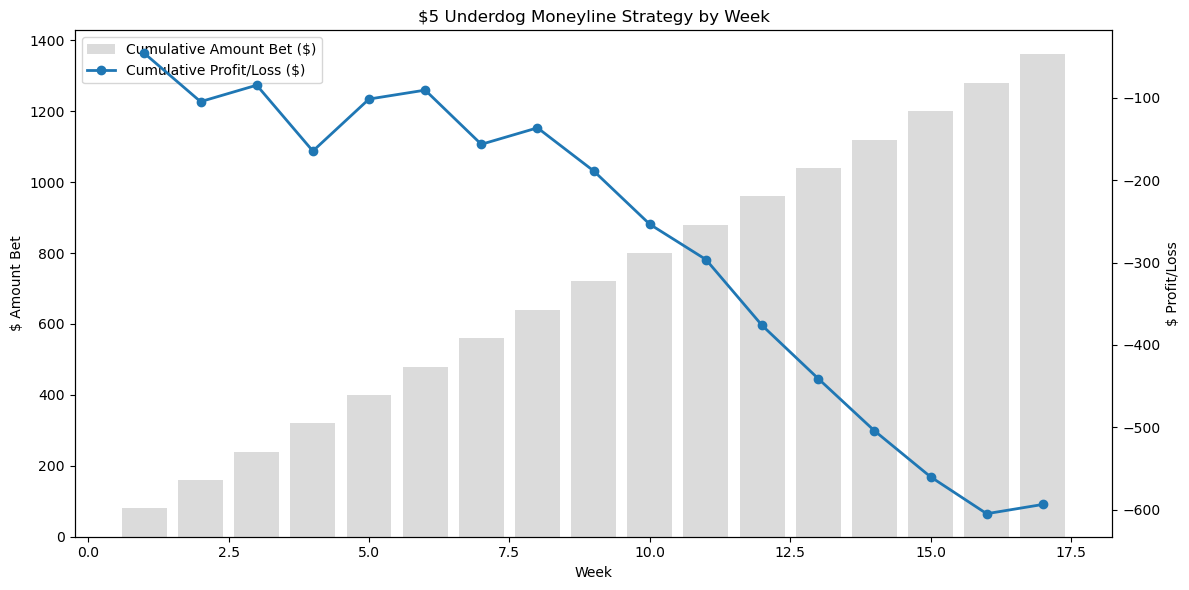

,week,weekly_profit_loss,weekly_bet_total,cumulative_profit_loss,cumulative_bet_total
0,1,-45.85,80.0,-45.85,80.0
1,2,-58.65,80.0,-104.50,160.0
2,3,20.00,80.0,-84.50,240.0
3,4,-80.00,80.0,-164.50,320.0
4,5,63.15,80.0,-101.35,400.0
5,6,10.85,80.0,-90.50,480.0
6,7,-65.80,80.0,-156.30,560.0
7,8,20.00,80.0,-136.30,640.0
8,9,-52.30,80.0,-188.60,720.0
9,10,-64.80,80.0,-253.40,800.0


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# File in repo root
file_path = "nfl_underdog_full_season.xlsx"

df = pd.read_excel(file_path)

# Normalize column names
normalized = {c: c.strip().lower().replace(" ", "_") for c in df.columns}


def find_col(candidates):
    """Find a matching column by exact or partial normalized name."""
    for original, norm in normalized.items():
        if norm in candidates:
            return original
    for original, norm in normalized.items():
        for cand in candidates:
            if cand in norm:
                return original
    return None

week_col = find_col({"week"})
underdog_col = find_col({"underdog_team", "underdog", "dog", "away_team", "team"})
underdog_ml_col = find_col({"underdog_moneyline", "moneyline", "ml", "underdog_ml"})
underdog_won_col = find_col({"underdog_won", "dog_won", "underdog_win"})

required = {
    "week": week_col,
    "underdog_team": underdog_col,
    "underdog_moneyline": underdog_ml_col,
    "underdog_won": underdog_won_col,
}

missing = [k for k, v in required.items() if v is None]
if missing:
    raise ValueError(
        f"Missing required columns: {missing}. Found columns: {list(df.columns)}"
    )

bets = df[[week_col, underdog_col, underdog_ml_col, underdog_won_col]].copy()
bets.columns = ["week", "underdog_team", "underdog_moneyline", "underdog_won"]

bets = bets.dropna(subset=["week", "underdog_team", "underdog_moneyline", "underdog_won"])
bets["week"] = pd.to_numeric(bets["week"], errors="coerce")
bets["underdog_moneyline"] = pd.to_numeric(bets["underdog_moneyline"], errors="coerce")
bets = bets.dropna(subset=["week", "underdog_moneyline"])

# Strategy: Bet $5 on every underdog moneyline
stake = 5.0


bets["bet_amount"] = stake
bets["underdog_won"] = bets["underdog_won"].astype(str).str.strip().str.lower().isin(["1", "true", "yes", "y"])
bets["profit_loss"] = bets.apply(
    lambda r: stake * (r["underdog_moneyline"] / 100.0) if r["underdog_won"] else -stake,
    axis=1,
)

weekly = (
    bets.groupby("week", as_index=False)
    .agg(weekly_profit_loss=("profit_loss", "sum"), weekly_bet_total=("bet_amount", "sum"))
    .sort_values("week")
)

weekly["cumulative_profit_loss"] = weekly["weekly_profit_loss"].cumsum()
weekly["cumulative_bet_total"] = weekly["weekly_bet_total"].cumsum()

# Plot: line for cumulative amount bet and line for cumulative profit/loss
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    weekly["week"],
    weekly["cumulative_bet_total"],
    color="gray",
    linestyle="--",
    marker="s",
    linewidth=2,
    label="Cumulative Amount Bet ($)",
)
ax1.set_xlabel("Week")
ax1.set_ylabel("$ Amount Bet")

ax2 = ax1.twinx()
ax2.plot(
    weekly["week"],
    weekly["cumulative_profit_loss"],
    color="tab:blue",
    marker="o",
    linewidth=2,
    label="Cumulative Profit/Loss ($)",
)
ax2.set_ylabel("$ Profit/Loss")

# Legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")

plt.title("$5 Underdog Moneyline Strategy by Week")
plt.tight_layout()
plt.show()

weekly

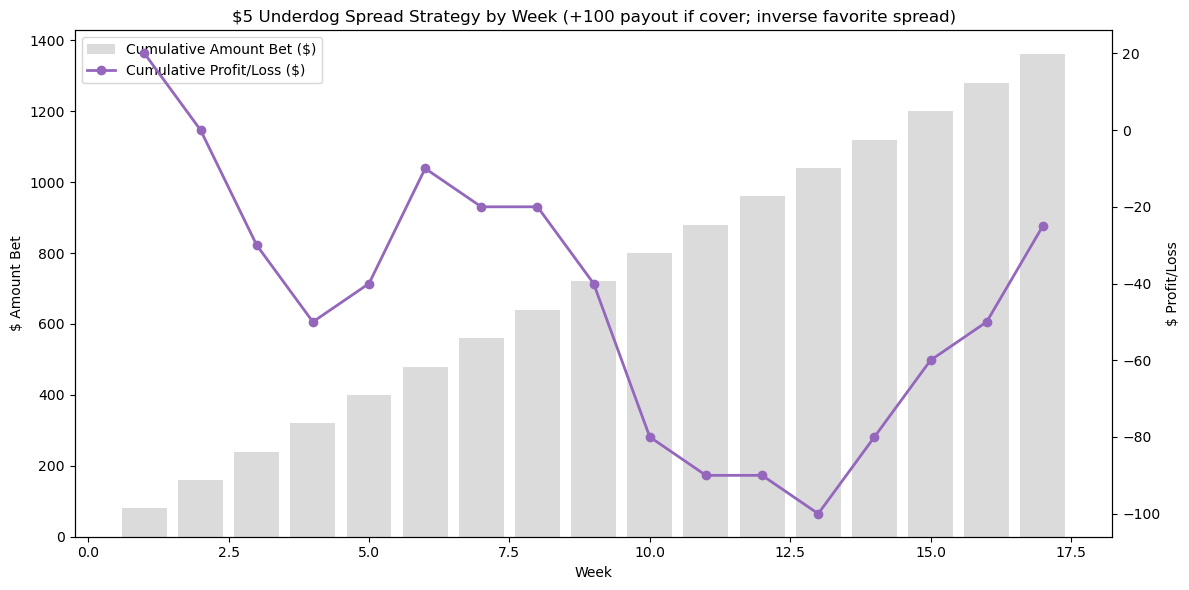

,week,weekly_profit_loss,weekly_bet_total,cumulative_profit_loss,cumulative_bet_total
0,1,20.0,80.0,20.0,80.0
1,2,-20.0,80.0,0.0,160.0
2,3,-30.0,80.0,-30.0,240.0
3,4,-20.0,80.0,-50.0,320.0
4,5,10.0,80.0,-40.0,400.0
5,6,30.0,80.0,-10.0,480.0
6,7,-10.0,80.0,-20.0,560.0
7,8,0.0,80.0,-20.0,640.0
8,9,-20.0,80.0,-40.0,720.0
9,10,-40.0,80.0,-80.0,800.0


In [4]:
# Essentially repoliate the above analysis but using the spread instead of the moneyline.

week_col = find_col({"week"})
spread_col = find_col({"spread", "favorite_spread", "line"})
favorite_score_col = find_col({"favorite_score", "fav_score"})
underdog_score_col = find_col({"underdog_score", "dog_score"})
required_cols = {
    "week": week_col,
    "spread": spread_col,
    "favorite_score": favorite_score_col,
    "underdog_score": underdog_score_col,
}
missing_cols = [k for k, v in required_cols.items() if v is None]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}. Found columns: {list(df.columns)}")

spread_bets = df[[week_col, spread_col, favorite_score_col, underdog_score_col]].copy()
spread_bets.columns = ["week", "favorite_spread", "favorite_score", "underdog_score"]

spread_bets["week"] = pd.to_numeric(spread_bets["week"], errors="coerce")
spread_bets["favorite_spread"] = pd.to_numeric(spread_bets["favorite_spread"], errors="coerce")
spread_bets["favorite_score"] = pd.to_numeric(spread_bets["favorite_score"], errors="coerce")
spread_bets["underdog_score"] = pd.to_numeric(spread_bets["underdog_score"], errors="coerce")
spread_bets = spread_bets.dropna()

# Spread is listed from favorite perspective, so invert for underdog.
spread_bets["underdog_spread"] = -spread_bets["favorite_spread"]
spread_bets["adjusted_dog_score"] = spread_bets["underdog_score"] + spread_bets["underdog_spread"]
spread_bets["underdog_covers"] = spread_bets["adjusted_dog_score"] > spread_bets["favorite_score"]
spread_bets["push"] = spread_bets["adjusted_dog_score"] == spread_bets["favorite_score"]

stake = 5.0
spread_bets["bet_amount"] = stake

# Spread bets at +100 (even money): profit on a win equals the stake.
win_profit = stake * (100 / 100.0)
spread_bets["profit_loss"] = spread_bets.apply(
    lambda r: 0.0 if r["push"] else (win_profit if r["underdog_covers"] else -stake),
    axis=1,
)

weekly_spread_inverse = (
    spread_bets.groupby("week", as_index=False)
    .agg(weekly_profit_loss=("profit_loss", "sum"), weekly_bet_total=("bet_amount", "sum"))
    .sort_values("week")
)

weekly_spread_inverse["cumulative_profit_loss"] = weekly_spread_inverse["weekly_profit_loss"].cumsum()
weekly_spread_inverse["cumulative_bet_total"] = weekly_spread_inverse["weekly_bet_total"].cumsum()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(
    weekly_spread_inverse["week"],
    weekly_spread_inverse["cumulative_bet_total"],
    color="gray",
    linestyle="--",
    marker="s",
    linewidth=2,
    label="Cumulative Amount Bet ($)",
)
ax1.set_xlabel("Week")
ax1.set_ylabel("$ Amount Bet")

ax2 = ax1.twinx()
ax2.plot(
    weekly_spread_inverse["week"],
    weekly_spread_inverse["cumulative_profit_loss"],
    color="tab:purple",
    marker="o",
    linewidth=2,
    label="Cumulative Profit/Loss ($)",
)
ax2.set_ylabel("$ Profit/Loss")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")

plt.title("$5 Underdog Spread Strategy by Week (+100 payout if cover; inverse favorite spread)")
plt.tight_layout()
plt.show()

weekly_spread_inverse

## Week 7 Feature Engineering (Clean Analysis DataFrame)



In [ ]:
import numpy as np
import pandas as pd

if "df" not in globals():
    df = pd.read_excel("nfl_underdog_full_season.xlsx")

work = df.copy()

# Build required core fields.
analysis_df = pd.DataFrame()
analysis_df["week"] = pd.to_numeric(work.get("week"), errors="coerce")
analysis_df["underdog_moneyline"] = pd.to_numeric(work.get("underdog_moneyline"), errors="coerce")
analysis_df["underdog_is_home"] = pd.to_numeric(work.get("underdog_is_home"), errors="coerce")
analysis_df["rest_diff"] = pd.to_numeric(work.get("rest_diff"), errors="coerce")

# Spread features.
analysis_df["favorite_spread"] = pd.to_numeric(work.get("spread"), errors="coerce")
analysis_df["underdog_spread"] = -analysis_df["favorite_spread"]
analysis_df["spread_abs"] = analysis_df["favorite_spread"].abs()

# Scores and outcomes.
fav_score = pd.to_numeric(work.get("favorite_score"), errors="coerce")
dog_score = pd.to_numeric(work.get("underdog_score"), errors="coerce")

if "underdog_won" in work.columns:
    uw = work["underdog_won"].astype(str).str.strip().str.lower().isin(["1", "true", "yes", "y"])
else:
    uw = dog_score > fav_score
analysis_df["underdog_won"] = uw

adjusted_dog_score = dog_score + analysis_df["underdog_spread"]
analysis_df["underdog_covered"] = adjusted_dog_score > fav_score
analysis_df["push"] = adjusted_dog_score == fav_score

# Implied probability from odds.
def american_to_implied_prob(odds):
    if pd.isna(odds):
        return np.nan
    if odds > 0:
        return 100.0 / (odds + 100.0)
    if odds < 0:
        return (-odds) / ((-odds) + 100.0)
    return np.nan

analysis_df["implied_prob_dog"] = analysis_df["underdog_moneyline"].apply(american_to_implied_prob)

# performance/efficiency deltas (dog - fav).
analysis_df["elo_gap_dog_minus_fav"] = pd.to_numeric(work.get("dog_elo"), errors="coerce") - pd.to_numeric(work.get("fav_elo"), errors="coerce")
analysis_df["pass_yards_gap_dog_minus_fav"] = pd.to_numeric(work.get("dog_pass_yards_pg"), errors="coerce") - pd.to_numeric(work.get("fav_pass_yards_pg"), errors="coerce")
analysis_df["rush_yards_gap_dog_minus_fav"] = pd.to_numeric(work.get("dog_rush_yards_pg"), errors="coerce") - pd.to_numeric(work.get("fav_rush_yards_pg"), errors="coerce")
analysis_df["pressure_rate_gap_dog_minus_fav"] = pd.to_numeric(work.get("dog_pressure_rate"), errors="coerce") - pd.to_numeric(work.get("fav_pressure_rate"), errors="coerce")
analysis_df["def_pass_rank_gap_dog_minus_fav"] = pd.to_numeric(work.get("dog_def_pass_rank"), errors="coerce") - pd.to_numeric(work.get("fav_def_pass_rank"), errors="coerce")
analysis_df["def_run_rank_gap_dog_minus_fav"] = pd.to_numeric(work.get("dog_def_run_rank"), errors="coerce") - pd.to_numeric(work.get("fav_def_run_rank"), errors="coerce")

# Missing-data handling.
core_required = [
    "week",
    "underdog_moneyline",
    "underdog_is_home",
    "rest_diff",
    "favorite_spread",
]
rows_before = len(analysis_df)
analysis_df = analysis_df.dropna(subset=core_required).copy()
rows_after = len(analysis_df)

# Median-impute 
optional_delta_cols = [
    "elo_gap_dog_minus_fav",
    "pass_yards_gap_dog_minus_fav",
    "rush_yards_gap_dog_minus_fav",
    "pressure_rate_gap_dog_minus_fav",
    "def_pass_rank_gap_dog_minus_fav",
    "def_run_rank_gap_dog_minus_fav",
]
for c in optional_delta_cols:
    analysis_df[c] = analysis_df[c].fillna(analysis_df[c].median())

analysis_df["underdog_is_home"] = analysis_df["underdog_is_home"].astype(bool)
analysis_df["underdog_won"] = analysis_df["underdog_won"].astype(bool)
analysis_df["underdog_covered"] = analysis_df["underdog_covered"].astype(bool)
analysis_df["push"] = analysis_df["push"].astype(bool)

print(f"Rows before dropping required-missing: {rows_before}")
print(f"Rows after dropping required-missing:  {rows_after}")
print("\nClean analysis_df shape:", analysis_df.shape)
print("\nColumns in analysis_df:")
print(analysis_df.columns.tolist())

analysis_df.head()

Rows before dropping required-missing: 272
Rows after dropping required-missing:  272

Clean analysis_df shape: (272, 17)

Columns in analysis_df:
['week', 'underdog_moneyline', 'underdog_is_home', 'rest_diff', 'favorite_spread', 'underdog_spread', 'spread_abs', 'underdog_won', 'underdog_covered', 'push', 'implied_prob_dog', 'elo_gap_dog_minus_fav', 'pass_yards_gap_dog_minus_fav', 'rush_yards_gap_dog_minus_fav', 'pressure_rate_gap_dog_minus_fav', 'def_pass_rank_gap_dog_minus_fav', 'def_run_rank_gap_dog_minus_fav']


,week,underdog_moneyline,underdog_is_home,rest_diff,favorite_spread,underdog_spread,spread_abs,underdog_won,underdog_covered,push,implied_prob_dog,elo_gap_dog_minus_fav,pass_yards_gap_dog_minus_fav,rush_yards_gap_dog_minus_fav,pressure_rate_gap_dog_minus_fav,def_pass_rank_gap_dog_minus_fav,def_run_rank_gap_dog_minus_fav
0,1,1900,True,3,-6.6,6.6,6.6,False,True,False,0.050000,-155.4,-27.9,-23.2,-0.028,-8,-2
1,1,1900,True,3,-7.3,7.3,7.3,False,True,False,0.050000,-154.0,5.6,-2.4,-0.117,-10,21
2,1,281,False,1,-2.3,2.3,2.3,False,False,False,0.262467,-0.1,54.3,-18.9,0.089,-15,-5
3,1,1900,False,1,-8.4,8.4,8.4,False,True,False,0.050000,-222.3,-46.4,8.0,-0.011,23,5
4,1,1900,False,0,-8.2,8.2,8.2,False,True,False,0.050000,-214.0,-29.4,-33.6,0.132,-9,-21


## Week 7 EDA + Modeling

This section adds:
- ROI by spread bucket
- ROI by home vs away underdog
- Underdog win rate by implied-odds bucket
- Season comparison fallback (early/mid/late week segments)
- Time-aware modeling for `underdog_covered` with Logistic Regression and Random Forest
- Model strategy ROI comparison vs baseline strategies

Baseline strategy summary


,strategy,bets,total_staked,total_profit,roi,win_rate
0,Baseline Moneyline (all underdogs),272,1360.0,-593.65,-0.436507,0.091912
1,"Baseline Spread (odds-based payout, all underd...",272,1360.0,9615.05,7.069890,0.485294


ROI by spread bucket


,spread_bucket,games,spread_profit,spread_staked,cover_rate,spread_roi
0,<=2.5,55,-14.60,275.0,0.272727,-0.053091
1,2.5-4.5,63,167.60,315.0,0.206349,0.532063
2,4.5-6.5,62,2417.05,310.0,0.467742,7.796935
3,>6.5,92,7045.00,460.0,0.815217,15.315217


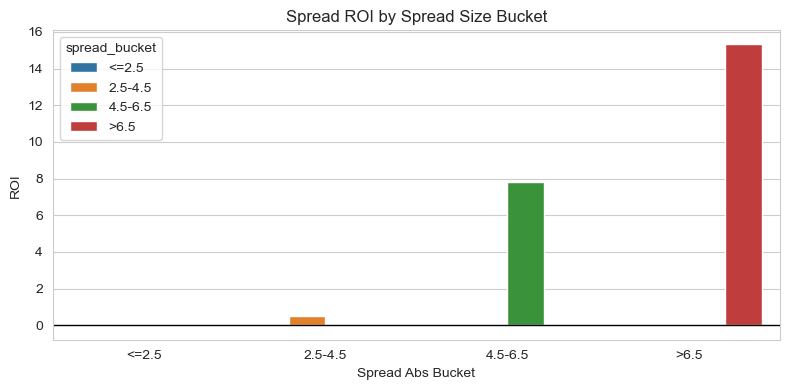

ROI by home vs away underdog


,dog_location,games,spread_profit,spread_staked,cover_rate,spread_roi
0,Away Underdog,144,5477.30,720.0,0.50000,7.607361
1,Home Underdog,128,4137.75,640.0,0.46875,6.465234


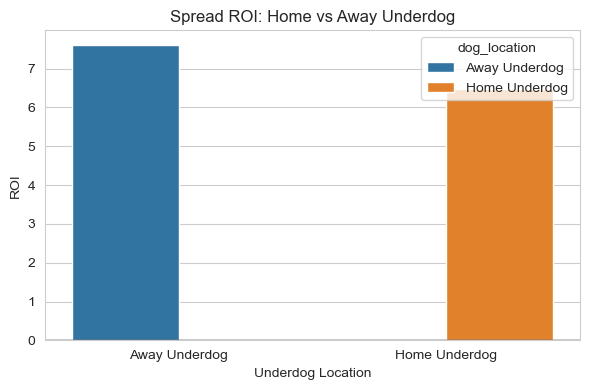

Underdog win rate by implied-odds bucket


,implied_bucket,games,underdog_win_rate,avg_implied_prob
0,<=20%,205,0.039024,0.069900
1,20-30%,48,0.229167,0.250508
2,30-40%,17,0.294118,0.340730
3,>40%,2,0.500000,0.404885


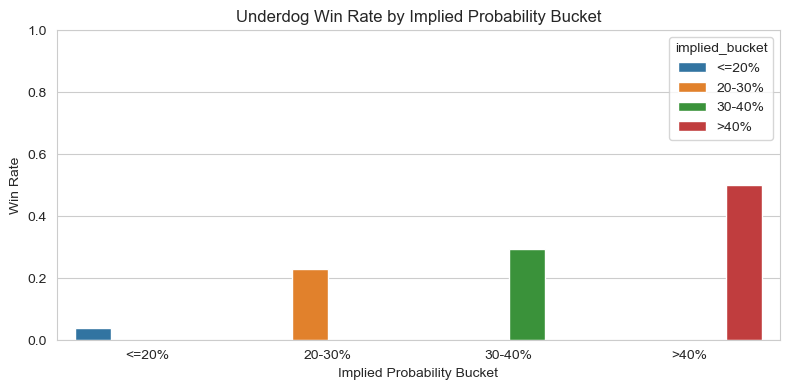

Season fallback comparison by week segment (season not available)


,week_segment,games,spread_profit,spread_staked,cover_rate,win_rate,spread_roi
0,Early,96,3309.45,480.0,0.489583,0.114583,6.894687
1,Mid,80,2173.75,400.0,0.387500,0.075000,5.434375
2,Late,96,4131.85,480.0,0.562500,0.083333,8.608021


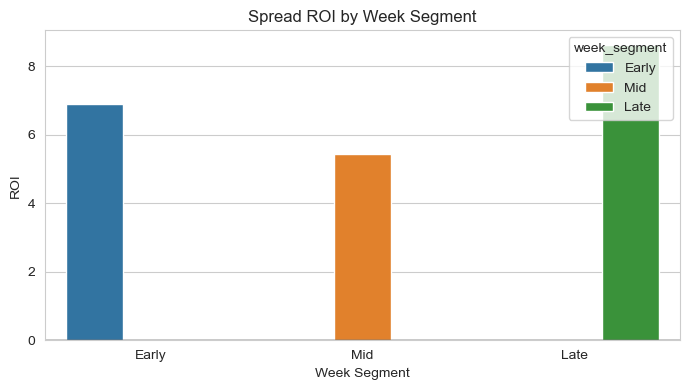

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

sns.set_style("whitegrid")

eda_df = analysis_df.copy()

stake = 5.0

# --- Baseline strategy metrics ---
# Moneyline baseline: $5 on every underdog to win.
def ml_profit(row):
    if row["underdog_won"]:
        odds = row["underdog_moneyline"]
        if odds > 0:
            return stake * (odds / 100.0)
        return stake * (100.0 / abs(odds))
    return -stake

eda_df["ml_profit"] = eda_df.apply(ml_profit, axis=1)
eda_df["ml_bet"] = stake


def odds_based_win_profit(odds, stake=5.0):
    if pd.isna(odds):
        return np.nan
    if odds > 0:
        return stake * (odds / 100.0)
    return stake * (100.0 / abs(odds))

eda_df["spread_profit"] = eda_df.apply(
    lambda r: 0.0 if r["push"] else (odds_based_win_profit(r["underdog_moneyline"], stake) if r["underdog_covered"] else -stake),
    axis=1,
)
eda_df["spread_bet"] = stake


def summarize_strategy(profit_col, bet_col):
    total_staked = eda_df[bet_col].sum()
    total_profit = eda_df[profit_col].sum()
    return {
        "bets": len(eda_df),
        "total_staked": total_staked,
        "total_profit": total_profit,
        "roi": total_profit / total_staked,
        "win_rate": (eda_df[profit_col] > 0).mean(),
    }

baseline_ml = summarize_strategy("ml_profit", "ml_bet")
baseline_spread = summarize_strategy("spread_profit", "spread_bet")

baseline_table = pd.DataFrame(
    [
        {"strategy": "Baseline Moneyline (all underdogs)", **baseline_ml},
        {"strategy": "Baseline Spread (odds-based payout, all underdogs)", **baseline_spread},
    ]
)
print("Baseline strategy summary")
display(baseline_table)

# --- 1) ROI by spread bucket ---
spread_bins = [-np.inf, 2.5, 4.5, 6.5, np.inf]
spread_labels = ["<=2.5", "2.5-4.5", "4.5-6.5", ">6.5"]
eda_df["spread_bucket"] = pd.cut(
    eda_df["spread_abs"], bins=spread_bins, labels=spread_labels, right=True
)

roi_spread_bucket = (
    eda_df.groupby("spread_bucket", observed=False)
    .agg(
        games=("week", "count"),
        spread_profit=("spread_profit", "sum"),
        spread_staked=("spread_bet", "sum"),
        cover_rate=("underdog_covered", "mean"),
    )
    .reset_index()
)
roi_spread_bucket["spread_roi"] = roi_spread_bucket["spread_profit"] / roi_spread_bucket["spread_staked"]
print("ROI by spread bucket")
display(roi_spread_bucket)

plt.figure(figsize=(8, 4))
sns.barplot(data=roi_spread_bucket, x="spread_bucket", y="spread_roi", hue="spread_bucket")
plt.axhline(0, color="black", linewidth=1)
plt.title("Spread ROI by Spread Size Bucket")
plt.xlabel("Spread Abs Bucket")
plt.ylabel("ROI")
plt.tight_layout()
plt.show()

# --- 2) ROI by home vs away underdog ---
eda_df["dog_location"] = np.where(eda_df["underdog_is_home"], "Home Underdog", "Away Underdog")
roi_home_away = (
    eda_df.groupby("dog_location")
    .agg(
        games=("week", "count"),
        spread_profit=("spread_profit", "sum"),
        spread_staked=("spread_bet", "sum"),
        cover_rate=("underdog_covered", "mean"),
    )
    .reset_index()
)
roi_home_away["spread_roi"] = roi_home_away["spread_profit"] / roi_home_away["spread_staked"]
print("ROI by home vs away underdog")
display(roi_home_away)

plt.figure(figsize=(6, 4))
sns.barplot(data=roi_home_away, x="dog_location", y="spread_roi", hue="dog_location")
plt.axhline(0, color="black", linewidth=1)
plt.title("Spread ROI: Home vs Away Underdog")
plt.xlabel("Underdog Location")
plt.ylabel("ROI")
plt.tight_layout()
plt.show()

# --- 3) Win rate by implied odds bucket ---
odds_bins = [0, 0.2, 0.3, 0.4, 1.0]
odds_labels = ["<=20%", "20-30%", "30-40%", ">40%"]
eda_df["implied_bucket"] = pd.cut(
    eda_df["implied_prob_dog"], bins=odds_bins, labels=odds_labels, include_lowest=True
)

winrate_implied = (
    eda_df.groupby("implied_bucket", observed=False)
    .agg(
        games=("week", "count"),
        underdog_win_rate=("underdog_won", "mean"),
        avg_implied_prob=("implied_prob_dog", "mean"),
    )
    .reset_index()
)
print("Underdog win rate by implied-odds bucket")
display(winrate_implied)

plt.figure(figsize=(8, 4))
sns.barplot(data=winrate_implied, x="implied_bucket", y="underdog_win_rate", hue="implied_bucket")
plt.title("Underdog Win Rate by Implied Probability Bucket")
plt.xlabel("Implied Probability Bucket")
plt.ylabel("Win Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# --- 4) Season comparison fallback ---
#compare early/mid/late by week.
wmin, wmax = int(eda_df["week"].min()), int(eda_df["week"].max())
week_edges = [wmin - 1, wmin + (wmax - wmin) / 3, wmin + 2 * (wmax - wmin) / 3, wmax]
eda_df["week_segment"] = pd.cut(
    eda_df["week"],
    bins=week_edges,
    labels=["Early", "Mid", "Late"],
    include_lowest=True,
)

segment_compare = (
    eda_df.groupby("week_segment", observed=False)
    .agg(
        games=("week", "count"),
        spread_profit=("spread_profit", "sum"),
        spread_staked=("spread_bet", "sum"),
        cover_rate=("underdog_covered", "mean"),
        win_rate=("underdog_won", "mean"),
    )
    .reset_index()
)
segment_compare["spread_roi"] = segment_compare["spread_profit"] / segment_compare["spread_staked"]
print("Season fallback comparison by week segment (season not available)")
display(segment_compare)

plt.figure(figsize=(7, 4))
sns.barplot(data=segment_compare, x="week_segment", y="spread_roi", hue="week_segment")
plt.axhline(0, color="black", linewidth=1)
plt.title("Spread ROI by Week Segment")
plt.xlabel("Week Segment")
plt.ylabel("ROI")
plt.tight_layout()
plt.show()



In [ ]:
model_df = eda_df.copy()

feature_cols = [
    "underdog_is_home",
    "rest_diff",
    "spread_abs",
    "underdog_spread",
    "implied_prob_dog",
    "elo_gap_dog_minus_fav",
    "pass_yards_gap_dog_minus_fav",
    "rush_yards_gap_dog_minus_fav",
    "pressure_rate_gap_dog_minus_fav",
    "def_pass_rank_gap_dog_minus_fav",
    "def_run_rank_gap_dog_minus_fav",
]

X = model_df[feature_cols].copy()
X["underdog_is_home"] = X["underdog_is_home"].astype(int)
y = model_df["underdog_covered"].astype(int)

# Time-aware split by week (train early weeks, test later weeks)
unique_weeks = sorted(model_df["week"].unique())
split_idx = max(1, int(len(unique_weeks) * 0.75))
cutoff_week = unique_weeks[split_idx - 1]

train_mask = model_df["week"] <= cutoff_week
test_mask = model_df["week"] > cutoff_week

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Time-aware split cutoff week: {cutoff_week}")
print(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")

Time-aware split cutoff week: 12
Train rows: 192, Test rows: 80


,model,accuracy,roc_auc,precision,recall
0,Logistic Regression,0.7375,0.768542,0.878788,0.630435


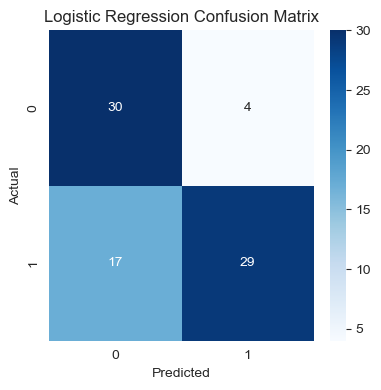

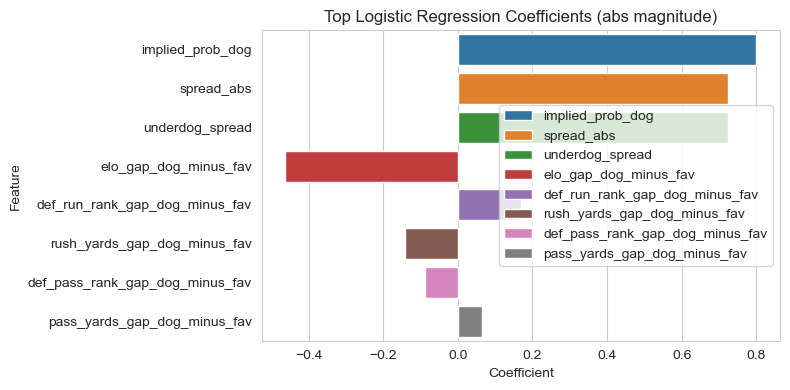

In [19]:
# Logistic Regression model
logit_pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42)),
    ]
)
logit_pipe.fit(X_train, y_train)

logit_proba = logit_pipe.predict_proba(X_test)[:, 1]
logit_pred = (logit_proba >= 0.5).astype(int)

def safe_roc_auc(y_true, y_score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)

logit_metrics = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "accuracy": accuracy_score(y_test, logit_pred),
        "roc_auc": safe_roc_auc(y_test, logit_proba),
        "precision": precision_score(y_test, logit_pred, zero_division=0),
        "recall": recall_score(y_test, logit_pred, zero_division=0),
    }
])
display(logit_metrics)

cm_logit = confusion_matrix(y_test, logit_pred)
plt.figure(figsize=(4, 4))
sns.heatmap(cm_logit, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

logit_coeffs = pd.Series(
    logit_pipe.named_steps["model"].coef_[0], index=feature_cols
).sort_values(key=np.abs, ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=logit_coeffs.values[:8], y=logit_coeffs.index[:8], hue=logit_coeffs.index[:8], dodge=False)
plt.title("Top Logistic Regression Coefficients (abs magnitude)")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

,model,accuracy,roc_auc,precision,recall
0,Random Forest,0.6875,0.734655,0.862069,0.543478


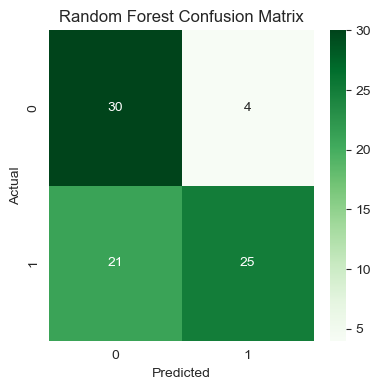

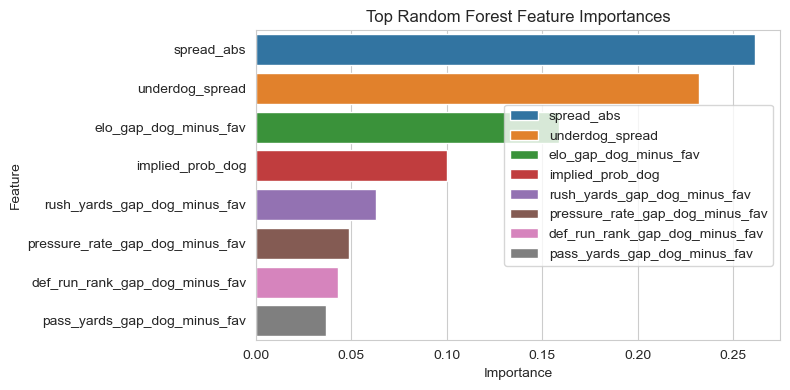

In [20]:
# Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=8,
    random_state=42,
)
rf_model.fit(X_train, y_train)

rf_proba = rf_model.predict_proba(X_test)[:, 1]
rf_pred = (rf_proba >= 0.5).astype(int)

rf_metrics = pd.DataFrame([
    {
        "model": "Random Forest",
        "accuracy": accuracy_score(y_test, rf_pred),
        "roc_auc": safe_roc_auc(y_test, rf_proba),
        "precision": precision_score(y_test, rf_pred, zero_division=0),
        "recall": recall_score(y_test, rf_pred, zero_division=0),
    }
])
display(rf_metrics)

cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(4, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

rf_importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=rf_importance.values[:8], y=rf_importance.index[:8], hue=rf_importance.index[:8], dodge=False)
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
# Model strategy vs baselines (test period)
test_eval = model_df.loc[test_mask].copy()
test_eval["logit_proba_cover"] = logit_proba
test_eval["rf_proba_cover"] = rf_proba


def odds_based_win_profit(odds, stake=5.0):
    if pd.isna(odds):
        return np.nan
    if odds > 0:
        return stake * (odds / 100.0)
    return stake * (100.0 / abs(odds))


def simulate_threshold_strategy(df_eval, prob_col, threshold, stake=5.0):
    out = df_eval.copy()
    out["bet_flag"] = out[prob_col] >= threshold

    def _profit(r):
        if not r["bet_flag"]:
            return 0.0
        if r["push"]:
            return 0.0
        return odds_based_win_profit(r["underdog_moneyline"], stake) if r["underdog_covered"] else -stake

    out["profit"] = out.apply(_profit, axis=1)
    out["staked"] = out["bet_flag"].astype(float) * stake

    total_staked = out["staked"].sum()
    total_profit = out["profit"].sum()
    bets = int(out["bet_flag"].sum())

    return {
        "threshold": threshold,
        "bets": bets,
        "total_staked": total_staked,
        "total_profit": total_profit,
        "roi": (total_profit / total_staked) if total_staked > 0 else np.nan,
        "hit_rate": (out.loc[out["bet_flag"], "profit"] > 0).mean() if bets > 0 else np.nan,
    }

thresholds = [0.55, 0.60]
logit_sim = pd.DataFrame([simulate_threshold_strategy(test_eval, "logit_proba_cover", t, 5.0) for t in thresholds])
logit_sim["strategy"] = "Logistic (cover threshold)"

rf_sim = pd.DataFrame([simulate_threshold_strategy(test_eval, "rf_proba_cover", t, 5.0) for t in thresholds])
rf_sim["strategy"] = "RandomForest (cover threshold)"

# Baselines over same test period
test_baseline_spread_staked = test_eval["spread_bet"].sum()
test_baseline_spread_profit = test_eval["spread_profit"].sum()
test_baseline_ml_staked = test_eval["ml_bet"].sum()
test_baseline_ml_profit = test_eval["ml_profit"].sum()

baseline_compare = pd.DataFrame([
    {
        "strategy": "Baseline Spread (odds-based payout, test period)",
        "threshold": np.nan,
        "bets": len(test_eval),
        "total_staked": test_baseline_spread_staked,
        "total_profit": test_baseline_spread_profit,
        "roi": test_baseline_spread_profit / test_baseline_spread_staked,
        "hit_rate": (test_eval["spread_profit"] > 0).mean(),
    },
    {
        "strategy": "Baseline Moneyline (test period)",
        "threshold": np.nan,
        "bets": len(test_eval),
        "total_staked": test_baseline_ml_staked,
        "total_profit": test_baseline_ml_profit,
        "roi": test_baseline_ml_profit / test_baseline_ml_staked,
        "hit_rate": (test_eval["ml_profit"] > 0).mean(),
    },
])

model_strategy_compare = pd.concat([baseline_compare, logit_sim, rf_sim], ignore_index=True)
display(model_strategy_compare.sort_values(["strategy", "threshold"], na_position="first"))


,strategy,threshold,bets,total_staked,total_profit,roi,hit_rate
1,Baseline Moneyline (test period),NaN,80,400.0,-217.40,-0.543500,0.100000
0,"Baseline Spread (odds-based payout, test period)",NaN,80,400.0,3411.85,8.529625,0.575000
2,Logistic (cover threshold),0.55,31,155.0,2550.00,16.451613,0.870968
3,Logistic (cover threshold),0.60,30,150.0,2455.00,16.366667,0.866667
4,RandomForest (cover threshold),0.55,27,135.0,2170.00,16.074074,0.851852
5,RandomForest (cover threshold),0.60,26,130.0,2075.00,15.961538,0.846154
